In [4]:
# importing packages
import numpy as np
import h5py

from src import io
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

In [5]:
exp_date = '250829'
exp_num = '1301'

experiment_path = io.get_experiment(exp_date, exp_num)
supervox_path = io.get_file(experiment_path, 'processed', '*supervoxels.h5')
labels_path = io.get_file(experiment_path, 'processed', '*labels.h5')
print(supervox_path, labels_path)

# open h5 and pull data
labels_hf = h5py.File(labels_path, 'r')
cluster_labels = labels_hf['labels'][...]

supervox_hf = h5py.File(supervox_path, 'r')

ca_signal = supervox_hf['ca_signal'][...]
fictrac_sp = supervox_hf['smoothed_speed'][...]
fictrac_t = supervox_hf['fictrac_time'][...]
camera_fr = supervox_hf['camera_fr'][...]
scope_fr = supervox_hf['scope_fr'][...]

# maui time conversions
frames = [x for x in range(1, ca_signal.shape[-1])]
volume_per_s = scope_fr/ca_signal.shape[0] # volume rate in Hz
maui_time = [0] + [x / volume_per_s for x in frames]

# fictrac time conversions
fic_time = fictrac_t / camera_fr

/Volumes/AhmedLab/princess/data/250829_1301/processed/250829_1301_supervoxels.h5 /Volumes/AhmedLab/princess/data/250829_1301/processed/TSeries-08292025-1301_channel_1_labels.h5


In [49]:
# to run pearson correlations, first downsize the fictrac data to match the calcium data size

def downsize_dataset(fast_ds, slow_ds):
    slow_signal = pd.DataFrame(slow_ds[slice_num, :, :].T)
    slow = slow_signal.to_numpy()
    fast = fast_ds

    max_divider = fast.shape[0] // slow.shape[0]
    fast_cut = fast[:slow.shape[0]*max_divider] # cut excess behavior data
    fast_reshaped = np.reshape(fast_cut, (slow.shape[0], -1))
    fast_downsample = np.mean(fast_reshaped, axis=1)
    print(fast_downsample.shape[0], slow.shape[0])

    return fast_downsample

def pearson_analysis(cluster_labels, resampled_behavior):
    pearson_arr = []
    for slice_idx, clusters, in enumerate(cluster_labels):
        for cluster_idx, signal in enumerate(clusters):
            corr = pearsonr(signal, resampled_behavior).statistic
            pearson_arr.append(corr)
    # pearson_arr_reshape = np.reshape(pearson_arr, (cluster_labels.shape[0], -1))

    return pearson_arr

def sort_descending(array):
    sort_ascending = np.argsort(array)
    flipped = np.flip(sort_ascending)
    return flipped

In [36]:
print(ca_signal.shape)

(31, 200, 670)


In [50]:
fictrac_resample = downsize_dataset(fictrac_sp, ca_signal)

pearson_arr = pearson_analysis(ca_signal, fictrac_resample)
sorted_pearson = sort_descending(pearson_arr)
print(len(pearson_arr)) # [slices, pearson coefficient of each roi]
print(sorted_pearson[0:10])

670 670
6200
[5262 2276 5186 1995 6164 2767 2531 3078 3890 2950]


In [44]:
signal_reshape = np.reshape(ca_signal, (ca_signal.shape[0]*ca_signal.shape[1], -1))

(6200, 670)


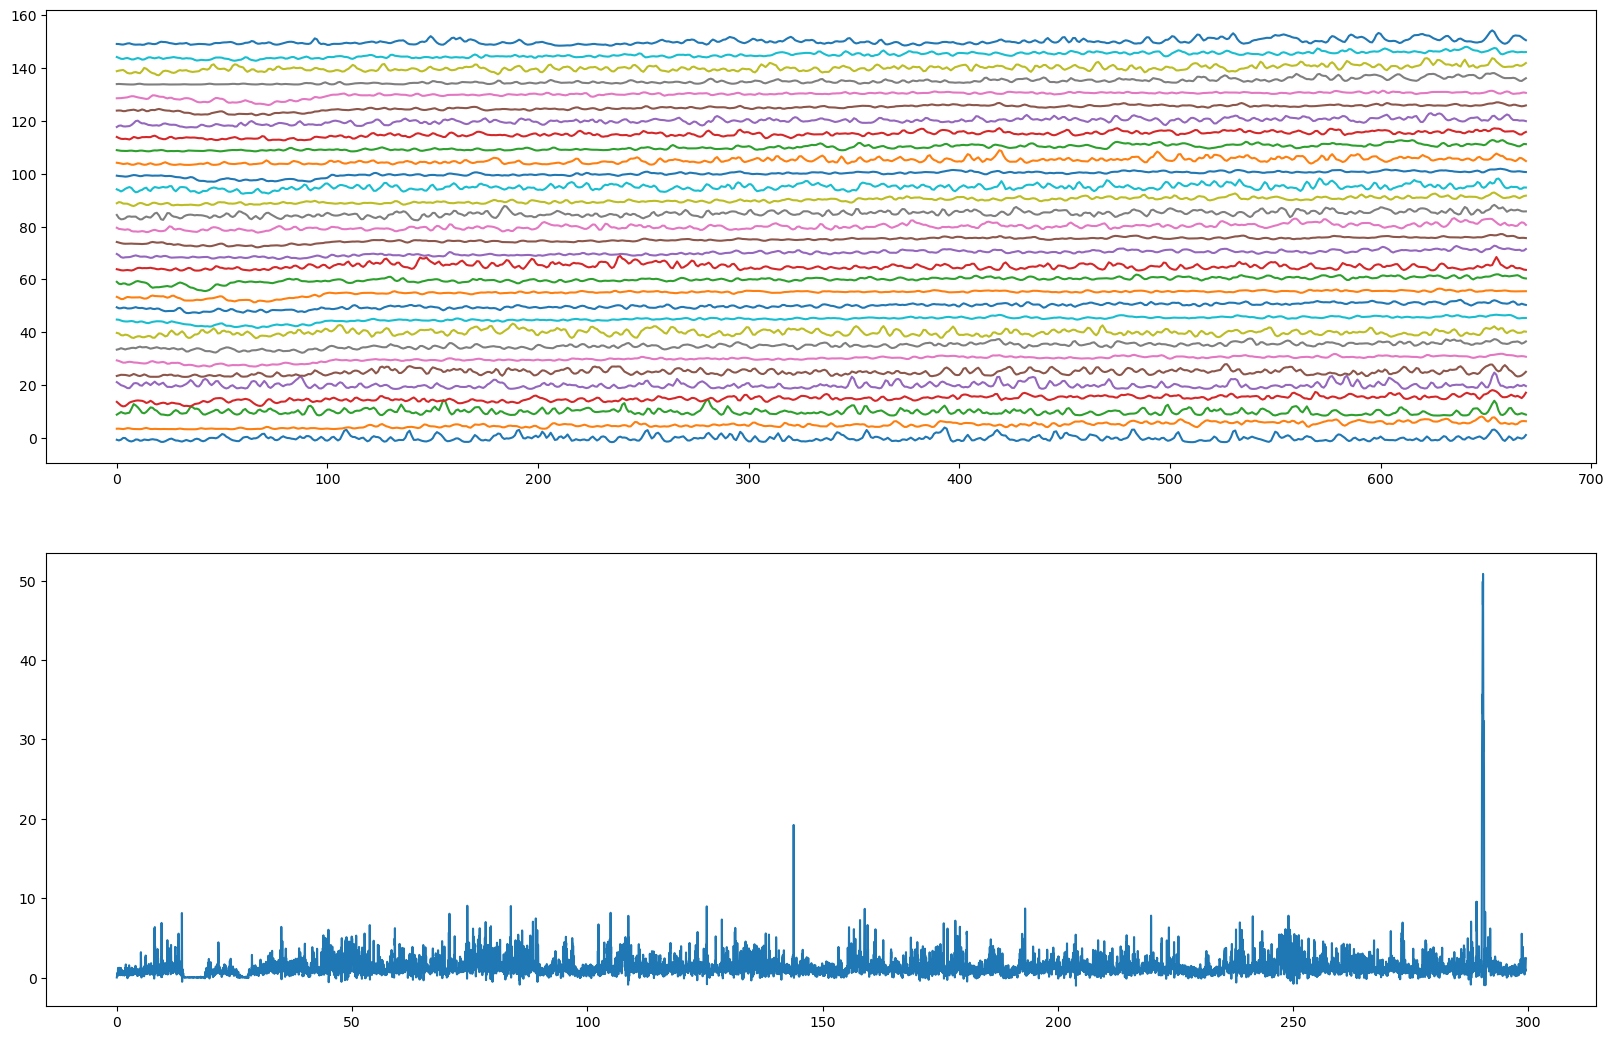

In [56]:
plt.figure(figsize=(20,20))
plt.subplot( 3, 1, 1)
for idx, cluster_idx in enumerate(sorted_pearson):
    trace = signal_reshape[cluster_idx, :] + (5*idx)
    plt.plot(trace)
    if idx == 30:
        break
plt.subplot(312)
plt.plot(fic_time, fictrac_sp)

In [57]:
cluster_labels.shape

(31, 44800)